# 📊 Milestone 2: Temporal Trend Analysis

## Objective
To analyze how disaster declarations have changed over time and identify key trends and seasonal patterns.

## Tasks Performed
- Yearly disaster trend analysis
- Monthly disaster seasonality analysis
- Incident type trends over time
- Disaster duration analysis

In [12]:
# ==============================
# Load and Prepare Data
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../dataset/us_disaster_declarations.csv")

# Convert date columns
df['declaration_date'] = pd.to_datetime(df['declaration_date'], errors='coerce')
df['incident_begin_date'] = pd.to_datetime(df['incident_begin_date'], errors='coerce')
df['incident_end_date'] = pd.to_datetime(df['incident_end_date'], errors='coerce')

# Create time features
df['year'] = df['declaration_date'].dt.year
df['month'] = df['declaration_date'].dt.month

# Create duration feature
df['duration_days'] = (df['incident_end_date'] - df['incident_begin_date']).dt.days

df.head()

,fema_declaration_string,disaster_number,state,declaration_type,declaration_date,fy_declared,incident_type,declaration_title,ih_program_declared,ia_program_declared,...,last_ia_filing_date,incident_id,region,designated_incident_types,last_refresh,hash,id,year,month,duration_days
0,DR-1-GA,1,GA,DR,1953-05-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,NaN,53013,4,NaN,2024-08-27T18:22:14Z,413ff808d79f08a6710f6b78f361d5a7de692711,8943dfcf-9786-4e51-8889-d62014034bb2,1953,5,0.0
1,DR-2-TX,2,TX,DR,1953-05-15 00:00:00+00:00,1953,Tornado,Tornado & Heavy Rainfall,0,1,...,NaN,53003,6,W,2024-08-27T18:22:14Z,8a8bc885c003cb873c201bb6a3a2771a6d84efb1,ff821327-6b90-4246-b19f-fff8c4b288a8,1953,5,0.0
2,DR-3-LA,3,LA,DR,1953-05-29 00:00:00+00:00,1953,Flood,Flood,0,1,...,NaN,53005,6,NaN,2024-08-27T18:22:14Z,b6e6f19ae3c0d2383b7b873b8495bd2770f2ff9a,cd461e08-5ac9-4e70-8507-9c7a3cbff265,1953,5,0.0
3,DR-4-MI,4,MI,DR,1953-06-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,NaN,53004,5,NaN,2024-08-27T18:22:14Z,34f0061012c8069f145d56a3537cd327b7d4e49b,53be0c04-d2ae-42fb-b070-a01b0a50b7f6,1953,6,0.0
4,DR-5-MT,5,MT,DR,1953-06-06 00:00:00+00:00,1953,Flood,Floods,0,1,...,NaN,53006,8,NaN,2024-08-27T18:22:14Z,3bdbec258e4640c3f02971dbc1f9dbc3ebbfc96a,4b3ed0ac-299b-49f0-80d4-9a2a6bacd5a4,1953,6,0.0


## 📈 Yearly Disaster Trend

This graph shows how disaster declarations have changed over the years. It helps identify long-term trends and growth patterns.

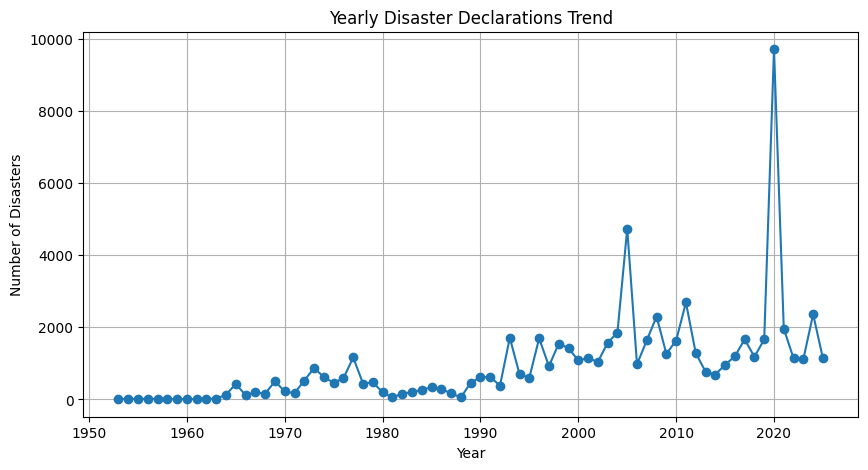

In [13]:
# ==============================
# Yearly Disaster Trend
# ==============================

yearly_trend = df.groupby('year').size()

plt.figure(figsize=(10,5))
yearly_trend.plot(marker='o')

plt.title("Yearly Disaster Declarations Trend")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.grid(True)

plt.show()

## 🌪️ Incident Type Trends Over Time

This visualization shows how different disaster types have occurred over time and highlights major contributing disaster categories.

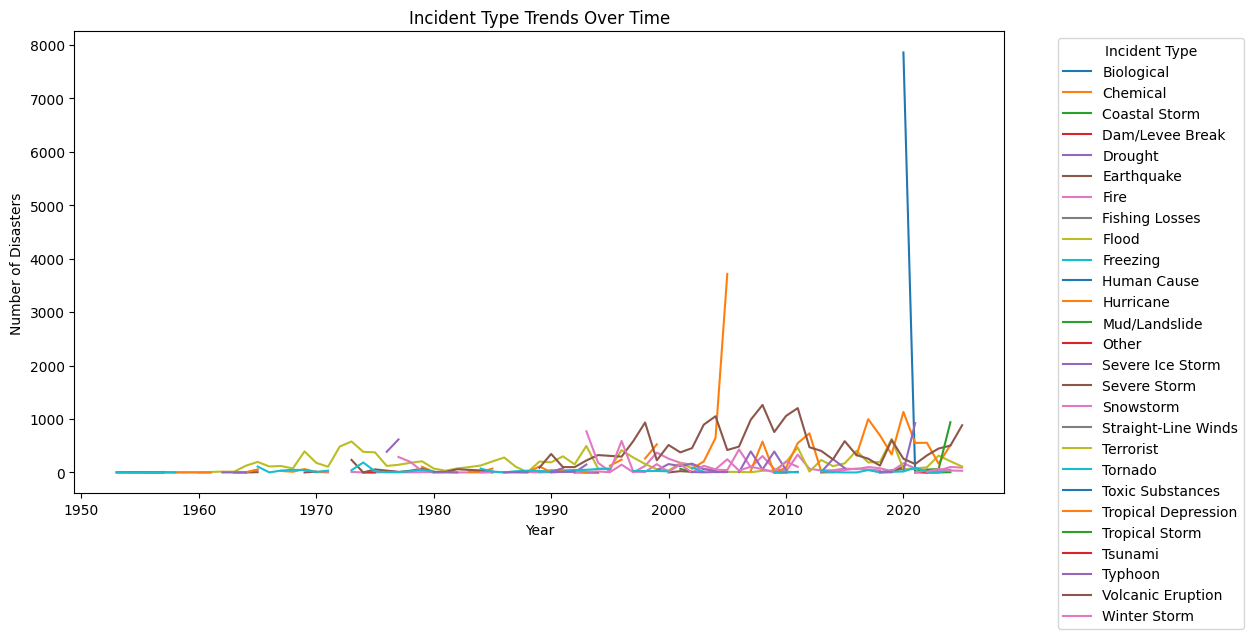

In [14]:
# ==============================
# Incident Type Trend Over Time
# ==============================

incident_trend = df.groupby(['year', 'incident_type']).size().unstack()

incident_trend.plot(figsize=(12,6))

plt.title("Incident Type Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend(title="Incident Type", bbox_to_anchor=(1.05, 1))
plt.show()

## 📅 Monthly Seasonality Analysis

This chart shows how disasters are distributed across different months, helping identify seasonal patterns.

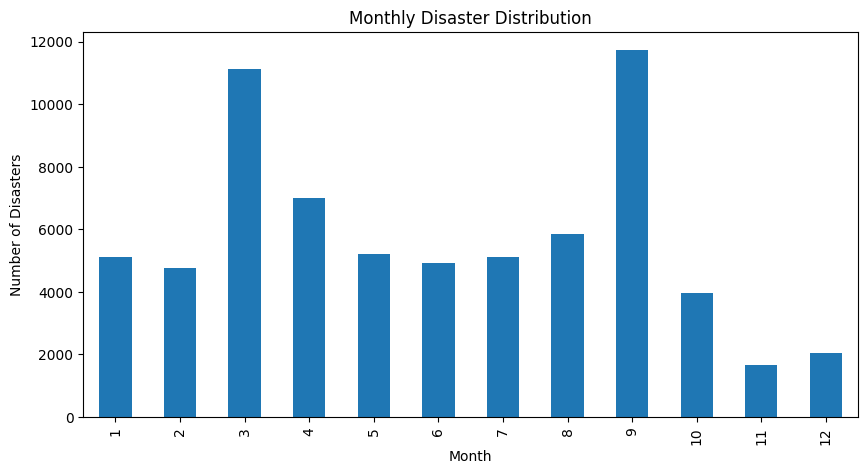

In [15]:
# ==============================
# Monthly Disaster Seasonality
# ==============================

monthly_trend = df.groupby('month').size()

plt.figure(figsize=(10,5))
monthly_trend.plot(kind='bar')

plt.title("Monthly Disaster Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")

plt.show()

## ⏳ Disaster Duration Analysis

This histogram shows how long disasters typically last, giving insights into their severity and duration patterns.

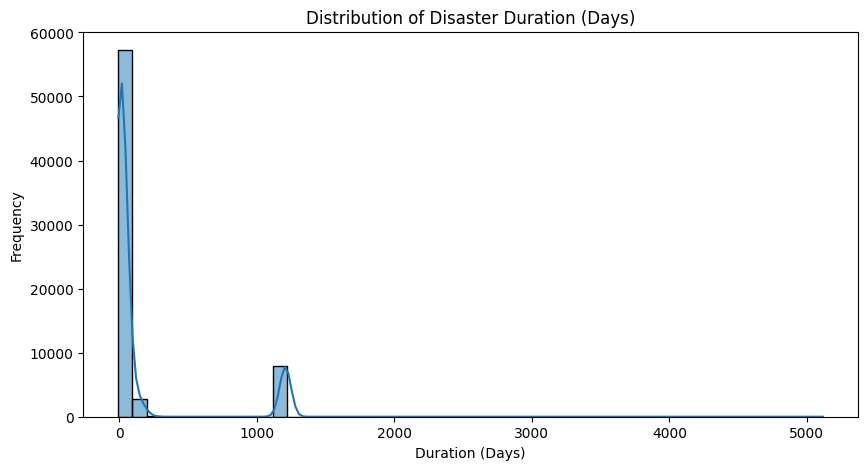

In [16]:
# ==============================
# Disaster Duration Analysis
# ==============================

plt.figure(figsize=(10,5))

sns.histplot(df['duration_days'].dropna(), bins=50, kde=True)

plt.title("Distribution of Disaster Duration (Days)")
plt.xlabel("Duration (Days)")
plt.ylabel("Frequency")

plt.show()

## 📈 Yearly Disaster Trend with Rolling Average

This graph represents the yearly disaster declarations along with a 3-year rolling average. The rolling average helps smooth short-term fluctuations and highlights long-term trends.

### Insight:
- Disaster declarations show a clear increasing trend over time.
- The rolling average confirms consistent long-term growth.
- Sudden spikes in recent years indicate extreme events or improved reporting systems.

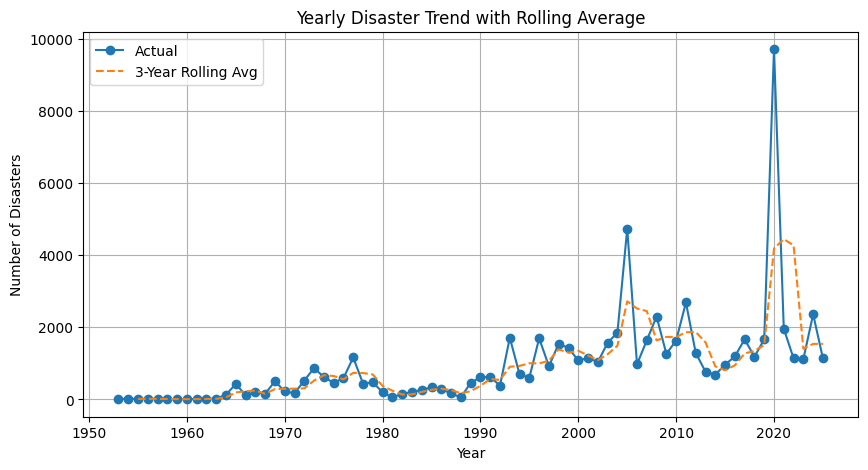

In [17]:
# ==============================
# Rolling Average Trend (Advanced)
# ==============================

yearly_trend = df.groupby('year').size()

rolling_avg = yearly_trend.rolling(window=3).mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_trend, label='Actual', marker='o')
plt.plot(rolling_avg, label='3-Year Rolling Avg', linestyle='--')

plt.title("Yearly Disaster Trend with Rolling Average")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend()
plt.grid(True)

plt.show()

## 🌪️ Top 5 Incident Types Over Time

This graph shows the trend of the top 5 most frequent disaster types across years. It helps identify which types of disasters contribute the most over time.

### Insight:
- Severe storms, floods, and hurricanes dominate disaster occurrences.
- Certain disaster types show sudden spikes, indicating extreme events.
- Some categories remain consistently high, reflecting persistent risks.

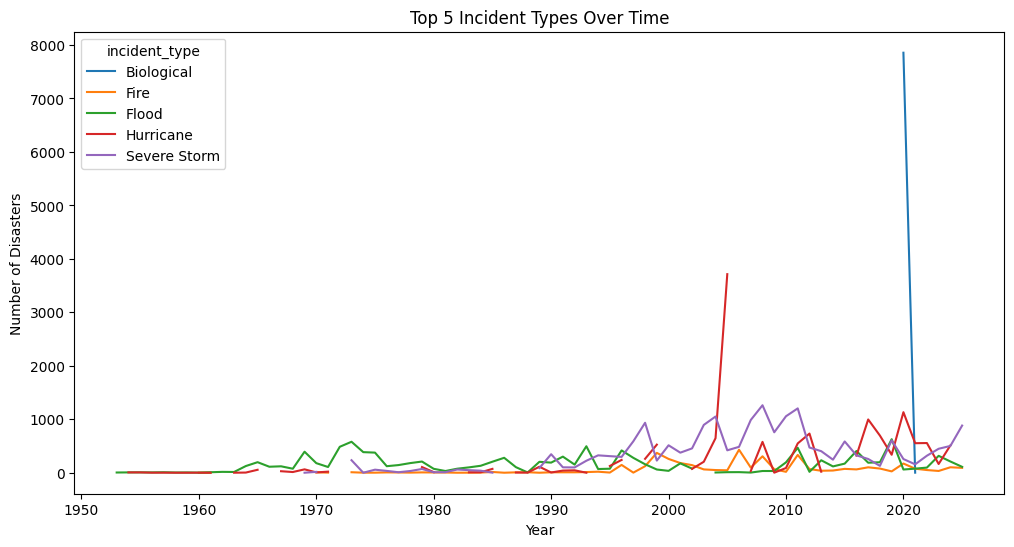

In [18]:
# Top 5 incident types
top_types = df['incident_type'].value_counts().head(5).index

filtered = df[df['incident_type'].isin(top_types)]

trend = filtered.groupby(['year', 'incident_type']).size().unstack()

trend.plot(figsize=(12,6))

plt.title("Top 5 Incident Types Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.show()

## ⏳ Average Disaster Duration per Year

This graph represents the average duration of disasters (in days) for each year. It helps understand how long disasters typically last over time.

### Insight:
- Most years show relatively stable duration patterns.
- Some years have extreme spikes, indicating unusually long-lasting disasters.
- Variations in duration reflect differences in disaster severity and type.

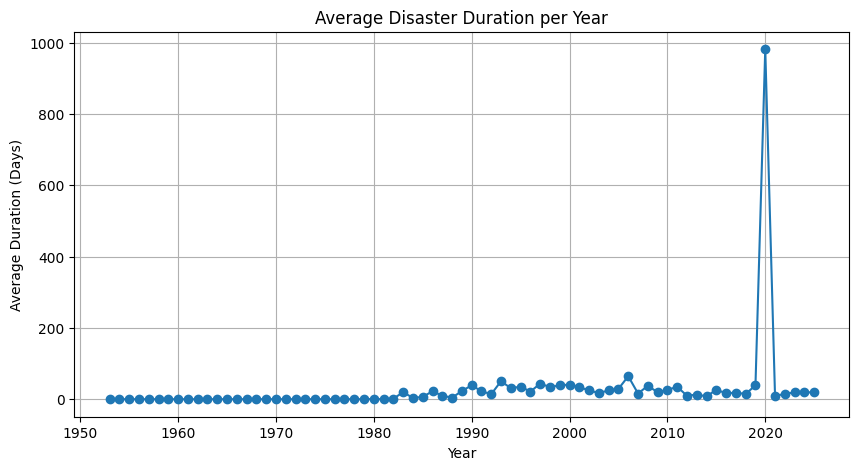

In [19]:
# ==============================
# Average Duration per Year
# ==============================

avg_duration = df.groupby('year')['duration_days'].mean()

plt.figure(figsize=(10,5))
avg_duration.plot(marker='o')

plt.title("Average Disaster Duration per Year")
plt.xlabel("Year")
plt.ylabel("Average Duration (Days)")

plt.grid(True)
plt.show()

## 📅 Monthly Disaster Trends (2010 Onwards)

This visualization shows how disaster occurrences vary across different months in recent years. It helps in identifying seasonal patterns.

### Insight:
- Certain months consistently show higher disaster frequency.
- Seasonal trends are visible, indicating climate-related patterns.
- Recent years show increased variability in monthly disaster occurrences.

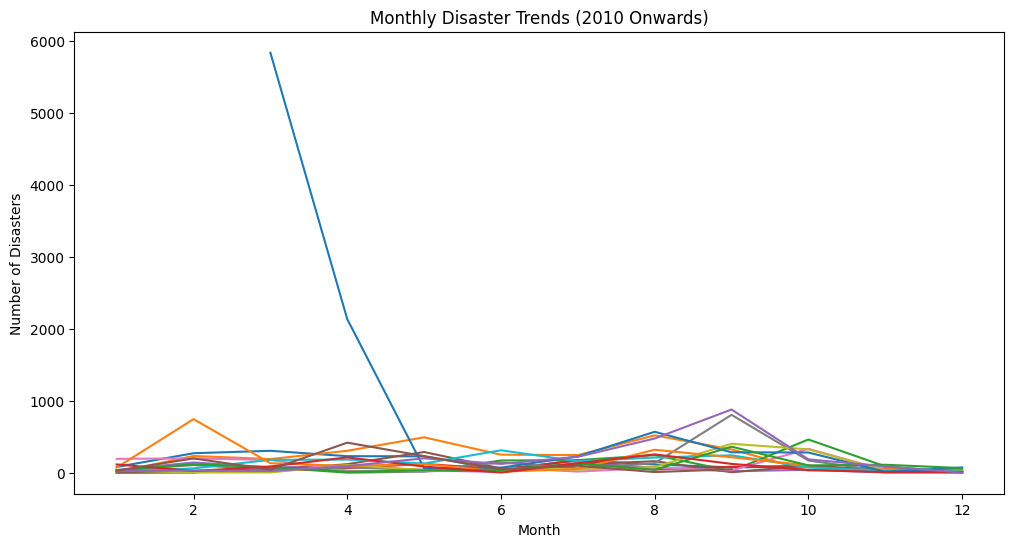

In [20]:
df_recent = df[df['year'] >= 2010]

monthly_year = df_recent.groupby(['year', 'month']).size().unstack()

monthly_year.T.plot(figsize=(12,6), legend=False)

plt.title("Monthly Disaster Trends (2010 Onwards)")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")

plt.show()

# 📊 Milestone 2: Temporal Trend Analysis

## Objective
To analyze disaster trends over time and identify patterns based on year, month, and incident type.

---

## 📈 Yearly Trend
Disaster declarations show an increasing trend over time, with recent years having higher frequency.

---

## 🌪️ Incident Type Trends
Severe storms, floods, and hurricanes are the most frequent disaster types, with consistent presence across years.

---

## 📅 Monthly Seasonality
Disasters follow seasonal patterns, with certain months showing higher occurrences.

---

## ⏳ Duration Analysis
Most disasters are short-term, but some years show longer durations due to severe events.

---

## 🔍 Conclusion
Disaster occurrences are increasing over time with clear seasonal patterns and dominant incident types, highlighting the need for better preparedness and planning.